In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import datasets, transforms

In [2]:
dataset_path = "/kaggle/input/datasets/pantho12/sar-cld-2024-dataset-for-cotton-leaf/SAR-CLD-2024 A Comprehensive Dataset for Cotton Leaf Disease Detection/Original Dataset/Original Dataset"
print(os.listdir(dataset_path))

['Curl Virus', 'Healthy Leaf', 'Leaf Hopper Jassids', 'Leaf Variegation', 'Leaf Redding', 'Bacterial Blight', 'Herbicide Growth Damage']


In [3]:
class MyDataSet(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        # Get class names
        self.classes = sorted(os.listdir(root_dir))

        # Map class name -> integer label
        self.class_to_idx = {
            cls_name: idx
            for idx, cls_name in enumerate(self.classes)
        }

        # Store (image_path, label) pairs
        self.samples = []
        for class_name in self.classes:
            class_folder = os.path.join(root_dir, class_name)
            for image_name in os.listdir(class_folder):
                image_path = os.path.join(class_folder, image_name)
                label = self.class_to_idx[class_name]
                self.samples.append((image_path, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        image_path, label = self.samples[i]
        image = Image.open(image_path).convert("RGB")
        image = self.transform(image)
        return image, label

In [4]:
no_transform = transforms.Compose([
                    transforms.Resize((128,128)),
                    transforms.ToTensor()
                ])
myds = MyDataSet(dataset_path,no_transform)
print(len(myds))
tds_size = int(0.8*len(myds))
vds_size = len(myds)-tds_size
print(tds_size)
print(vds_size)

tds,vds = random_split(myds,[tds_size,vds_size])


tdl = DataLoader(tds,batch_size=32,shuffle=True)
vdl = DataLoader(vds,batch_size=32,shuffle=True)

2137
1709
428


Text(0.5, 1.0, '3')

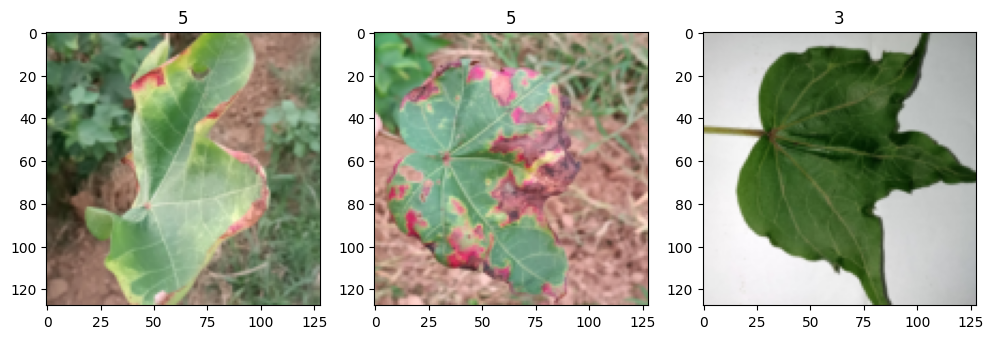

In [5]:
img , lbl = myds[1600]
timg, tlbl = tds[1600]
vimg, vlbl = vds[400]

fig, ax = plt.subplots(1, 3, figsize=(12,4))

ax[0].imshow(img.permute(1,2,0))
ax[0].set_title(lbl)

ax[1].imshow(timg.permute(1,2,0))
ax[1].set_title(tlbl)

ax[2].imshow(vimg.permute(1,2,0))
ax[2].set_title(vlbl)

In [6]:
class myModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(3,16,kernel_size=3,padding=1)
    self.conv2 = nn.Conv2d(16,32,kernel_size=3,padding=1)
    self.conv3 = nn.Conv2d(32,64,kernel_size=3,padding=1)
    self.pool = nn.MaxPool2d(2)
    self.relu = nn.ReLU()
    self.flatten = nn.Flatten()
    self.fc1 = nn.Linear(64*16*16, 128)
    self.fc2 = nn.Linear(128, 7)

  def forward(self,x):
    x = self.pool(self.relu(self.conv1(x)))
    x = self.pool(self.relu(self.conv2(x)))
    x = self.pool(self.relu(self.conv3(x)))
    x = self.flatten(x)
    x = self.relu(self.fc1(x))
    x = self.fc2(x)
    return x

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = myModel().to(device)
print(device)

cuda


In [8]:
def train(model, train_ld, val_ld, epochs, lr=0.0001):
    loss_func = nn.CrossEntropyLoss()
    opt = optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [],"val_loss": [],"train_acc": [],"val_acc": []}

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for img, lbl in train_ld:
            img, lbl = img.to(device), lbl.to(device)

            opt.zero_grad()
            prediction = model(img)
            loss = loss_func(prediction, lbl)
            loss.backward()
            opt.step()

            running_loss += loss.item() * img.size(0)
            correct += (prediction.argmax(1) == lbl).sum().item()
            total += lbl.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        model.eval()
        running_loss, correct, total = 0.0, 0, 0

        with torch.no_grad():
            for imgs, labels in val_ld:
                imgs, labels = imgs.to(device), labels.to(device)

                outputs = model(imgs)
                loss = loss_func(outputs, labels)

                running_loss += loss.item() * imgs.size(0)
                correct += (outputs.argmax(1) == labels).sum().item()
                total += labels.size(0)

        val_loss = running_loss / total
        val_acc = correct / total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch+1:2d}/{epochs} | "
            f"train_loss={train_loss:.3f} train_acc={train_acc:.3f} | "
            f"val_loss={val_loss:.3f} val_acc={val_acc:.3f}"
        )

    return history

In [9]:
history_plain = train(model, tdl, vdl, epochs=50)

Epoch  1/50 | train_loss=1.849 train_acc=0.267 | val_loss=1.805 val_acc=0.283
Epoch  2/50 | train_loss=1.777 train_acc=0.277 | val_loss=1.692 val_acc=0.357
Epoch  3/50 | train_loss=1.606 train_acc=0.372 | val_loss=1.508 val_acc=0.397
Epoch  4/50 | train_loss=1.430 train_acc=0.447 | val_loss=1.347 val_acc=0.484
Epoch  5/50 | train_loss=1.302 train_acc=0.494 | val_loss=1.260 val_acc=0.502
Epoch  6/50 | train_loss=1.230 train_acc=0.532 | val_loss=1.221 val_acc=0.519
Epoch  7/50 | train_loss=1.162 train_acc=0.557 | val_loss=1.225 val_acc=0.528
Epoch  8/50 | train_loss=1.110 train_acc=0.587 | val_loss=1.150 val_acc=0.547
Epoch  9/50 | train_loss=1.070 train_acc=0.606 | val_loss=1.088 val_acc=0.596
Epoch 10/50 | train_loss=1.043 train_acc=0.611 | val_loss=1.069 val_acc=0.589
Epoch 11/50 | train_loss=0.978 train_acc=0.638 | val_loss=1.063 val_acc=0.598
Epoch 12/50 | train_loss=0.962 train_acc=0.641 | val_loss=1.021 val_acc=0.607
Epoch 13/50 | train_loss=0.929 train_acc=0.648 | val_loss=0.994 

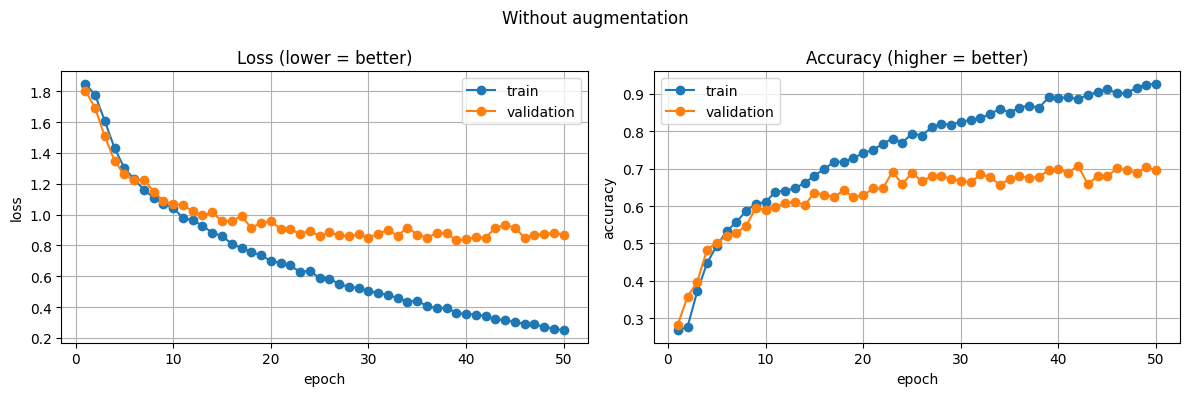

In [10]:
def plot_history(history, title=""):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epochs, history["train_loss"], "o-", label="train")
    ax1.plot(epochs, history["val_loss"],   "o-", label="validation")
    ax1.set_title("Loss (lower = better)")
    ax1.set_xlabel("epoch"); ax1.set_ylabel("loss"); ax1.legend(); ax1.grid(True)

    ax2.plot(epochs, history["train_acc"], "o-", label="train")
    ax2.plot(epochs, history["val_acc"],   "o-", label="validation")
    ax2.set_title("Accuracy (higher = better)")
    ax2.set_xlabel("epoch"); ax2.set_ylabel("accuracy"); ax2.legend(); ax2.grid(True)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_history(history_plain, "Without augmentation")

In [11]:
from torch.utils.data import random_split, Subset

normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

train_transform = transforms.Compose([
    # slightly larger resize
    transforms.Resize((160, 160)),

    # random crop for better generalization
    transforms.RandomResizedCrop(
        128,
        scale=(0.80, 1.0),
        ratio=(0.90, 1.10)
    ),

    # natural orientation changes
    transforms.RandomHorizontalFlip(p=0.5),

    # small rotation only
    transforms.RandomRotation(8),

    # mild lighting variation
    transforms.ColorJitter(
        brightness=0.10,
        contrast=0.10,
        saturation=0.08,
        hue=0.015
    ),

    # occasional blur
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))
    ], p=0.08),

    transforms.ToTensor(),
    normalize,

    # helps reduce overfitting
    transforms.RandomErasing(
        p=0.20,
        scale=(0.02, 0.06),
        ratio=(0.3, 3.3),
        value='random'
    )
])

val_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),normalize
])

train_dataset = MyDataSet(dataset_path, train_transform)
val_dataset = MyDataSet(dataset_path, val_transform)

dataset_size = len(train_dataset)

train_size = int(0.8 * dataset_size)
val_size = dataset_size - train_size

train_subset, val_subset = random_split(
    range(dataset_size),
    [train_size, val_size]
)

_tds = Subset(train_dataset, train_subset.indices)
_vds = Subset(val_dataset, val_subset.indices)

_tdl = DataLoader(_tds, batch_size=32, shuffle=True)
_vdl = DataLoader(_vds, batch_size=32, shuffle=False)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.622571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


Text(0.5, 1.0, '1')

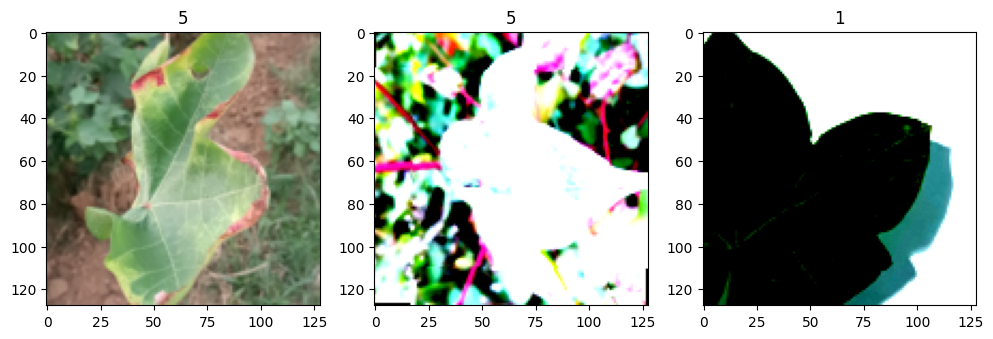

In [12]:
img , lbl = myds[1600]
timg, tlbl = _tds[1600]
vimg, vlbl = _vds[400]

fig, ax = plt.subplots(1, 3, figsize=(12,4))

ax[0].imshow(img.permute(1,2,0))
ax[0].set_title(lbl)

ax[1].imshow(timg.permute(1,2,0))
ax[1].set_title(tlbl)

ax[2].imshow(vimg.permute(1,2,0))
ax[2].set_title(vlbl)

Epoch  1/50 | train_loss=1.772 train_acc=0.297 | val_loss=1.640 val_acc=0.388
Epoch  2/50 | train_loss=1.477 train_acc=0.428 | val_loss=1.326 val_acc=0.519
Epoch  3/50 | train_loss=1.206 train_acc=0.534 | val_loss=1.166 val_acc=0.549
Epoch  4/50 | train_loss=1.099 train_acc=0.578 | val_loss=1.040 val_acc=0.603
Epoch  5/50 | train_loss=1.007 train_acc=0.613 | val_loss=1.073 val_acc=0.549
Epoch  6/50 | train_loss=0.962 train_acc=0.647 | val_loss=1.002 val_acc=0.603
Epoch  7/50 | train_loss=0.928 train_acc=0.645 | val_loss=0.934 val_acc=0.626
Epoch  8/50 | train_loss=0.897 train_acc=0.651 | val_loss=0.921 val_acc=0.643
Epoch  9/50 | train_loss=0.881 train_acc=0.672 | val_loss=0.968 val_acc=0.614
Epoch 10/50 | train_loss=0.854 train_acc=0.685 | val_loss=0.887 val_acc=0.657
Epoch 11/50 | train_loss=0.837 train_acc=0.689 | val_loss=0.982 val_acc=0.610
Epoch 12/50 | train_loss=0.810 train_acc=0.696 | val_loss=0.895 val_acc=0.645
Epoch 13/50 | train_loss=0.788 train_acc=0.703 | val_loss=0.842 

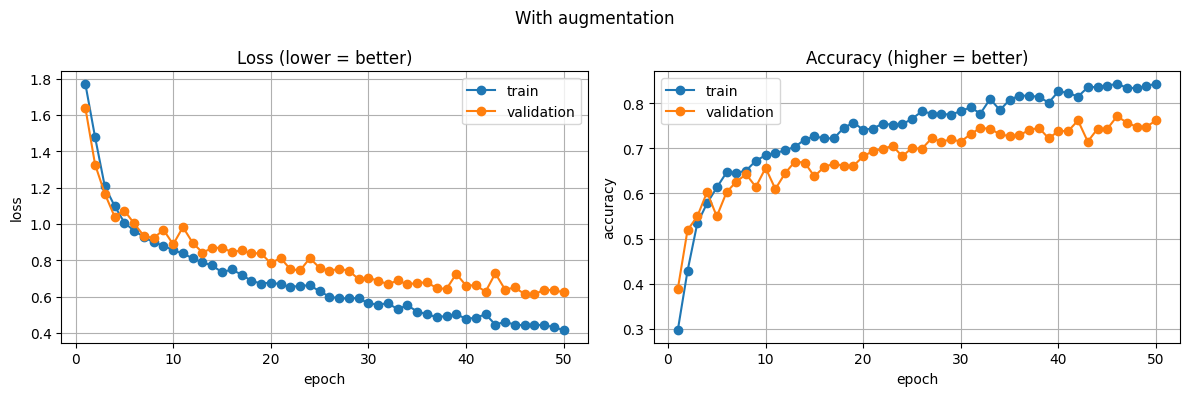

In [13]:
_model = myModel().to(device)

_history = train(_model,_tdl,_vdl,epochs=50)
plot_history(_history,"With augmentation")

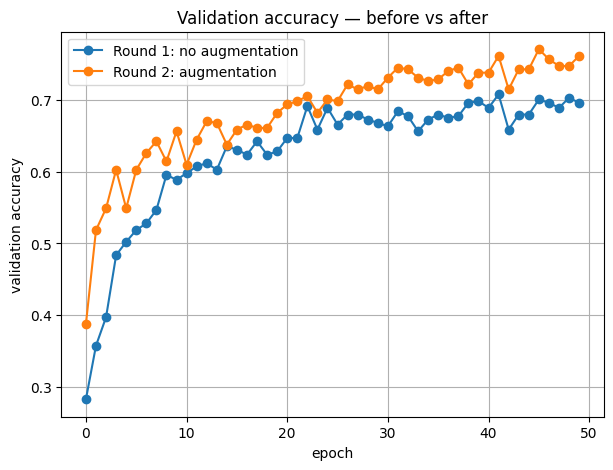

Best val acc  (Round 1): 0.708
Best val acc  (Round 2): 0.771


In [14]:
plt.figure(figsize=(7, 5))
plt.plot(history_plain["val_acc"], "o-", label="Round 1: no augmentation")
plt.plot(_history["val_acc"],   "o-", label="Round 2: augmentation")
plt.title("Validation accuracy — before vs after")
plt.xlabel("epoch"); plt.ylabel("validation accuracy")
plt.legend(); plt.grid(True)
plt.show()

print(f"Best val acc  (Round 1): {max(history_plain['val_acc']):.3f}")
print(f"Best val acc  (Round 2): {max(_history['val_acc']):.3f}")

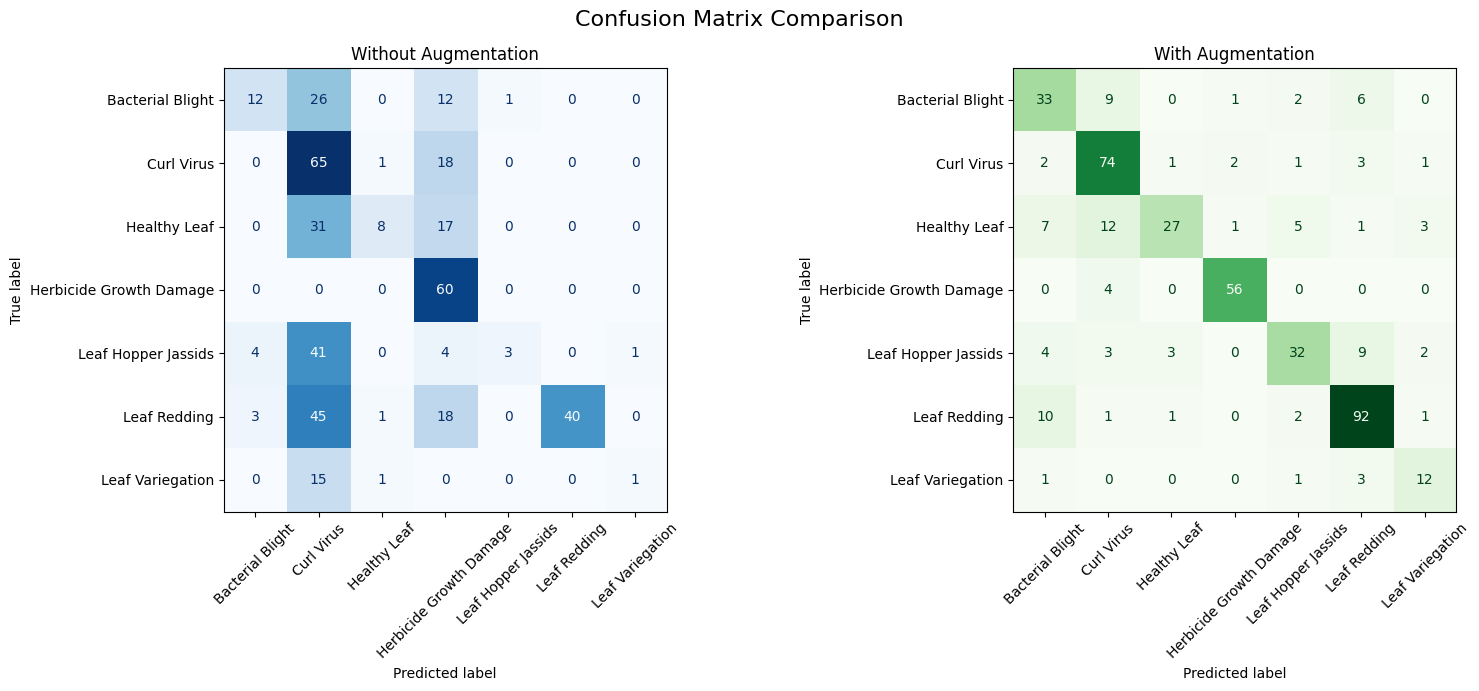

===== WITHOUT AUGMENTATION =====
                         precision    recall  f1-score   support

       Bacterial Blight       0.63      0.24      0.34        51
             Curl Virus       0.29      0.77      0.42        84
           Healthy Leaf       0.73      0.14      0.24        56
Herbicide Growth Damage       0.47      1.00      0.63        60
    Leaf Hopper Jassids       0.75      0.06      0.11        53
           Leaf Redding       1.00      0.37      0.54       107
       Leaf Variegation       0.50      0.06      0.11        17

               accuracy                           0.44       428
              macro avg       0.62      0.38      0.34       428
           weighted avg       0.66      0.44      0.40       428

===== WITH AUGMENTATION =====
                         precision    recall  f1-score   support

       Bacterial Blight       0.58      0.65      0.61        51
             Curl Virus       0.72      0.88      0.79        84
           Healthy Leaf

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import torch

# trained without augmentation
model_unaug = model

# trained with augmentation
model_aug = _model

def get_predictions(model, loader):
    model.eval()
    preds = []
    targets = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            preds.extend(outputs.argmax(dim=1).cpu().numpy())
            targets.extend(labels.cpu().numpy())

    return targets, preds


class_names = [
    "Bacterial Blight",
    "Curl Virus",
    "Healthy Leaf",
    "Herbicide Growth Damage",
    "Leaf Hopper Jassids",
    "Leaf Redding",
    "Leaf Variegation"
]

# Predictions
y_true_unaug, y_pred_unaug = get_predictions(model_unaug, _vdl)
y_true_aug, y_pred_aug = get_predictions(model_aug, _vdl)

# Confusion matrices
cm_unaug = confusion_matrix(y_true_unaug, y_pred_unaug)
cm_aug = confusion_matrix(y_true_aug, y_pred_aug)

# Create one figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Unaugmented
disp1 = ConfusionMatrixDisplay(
    confusion_matrix=cm_unaug,
    display_labels=class_names
)
disp1.plot(ax=axes[0], cmap="Blues", values_format="d", colorbar=False)
axes[0].set_title("Without Augmentation")
axes[0].tick_params(axis='x', rotation=45)

# Augmented
disp2 = ConfusionMatrixDisplay(
    confusion_matrix=cm_aug,
    display_labels=class_names
)
disp2.plot(ax=axes[1], cmap="Greens", values_format="d", colorbar=False)
axes[1].set_title("With Augmentation")
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle("Confusion Matrix Comparison", fontsize=16)
plt.tight_layout()
plt.show()

print("===== WITHOUT AUGMENTATION =====")
print(classification_report(y_true_unaug, y_pred_unaug, target_names=class_names))

print("===== WITH AUGMENTATION =====")
print(classification_report(y_true_aug, y_pred_aug, target_names=class_names))